In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install torch torch-geometric giotto-tda matplotlib RDKit

In [3]:
!pip install e3nn

In [4]:
import os
import pandas as pd
import torch
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from e3nn.io import CartesianTensor
from e3nn import o3
from e3nn.nn import Gate, BatchNorm
from e3nn.o3 import FullyConnectedTensorProduct
from torch_geometric.nn import global_mean_pool
import numpy as np
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from torch import nn



Загрузка датасета

In [5]:
data = torch.load('/content/drive/MyDrive/qm9s.pt', weights_only=False)

# проверим содержимое
if isinstance(data, list):
    print(f"всего молекул: {len(data)}")
    print("структура первой молекулы:")
    print(data[0])
else:
    print("структура файла:")
    print(data)

всего молекул: 129817
структура первой молекулы:
Data(edge_index=[2, 20], pos=[5, 3], number=1, smile='C', z=[5], quadrupole=[1, 3, 3], octapole=[1, 3, 3, 3], npacharge=[5], dipole=[1, 3], polar=[1, 3, 3], hyperpolar=[1, 3, 3, 3], energy=[1, 1], Hij=[20, 3, 3], Hi=[5, 3, 3], dedipole=[5, 3, 3], depolar=[5, 3, 6], tran_dipole=[1, 10, 3], tran_energy=[1, 10])


Класс для TDA характеристик

In [6]:
class QM9S_TDA(Dataset):
    def __init__(self, pyg_pt_path):
        super().__init__()
        self.raw_data = torch.load(pyg_pt_path, weights_only=False)

        # TDA экстрактор
        self.vr = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
        self.pe = PersistenceEntropy()

    def len(self):
        return len(self.raw_data)

    def get(self, idx):
        data = self.raw_data[idx]

        coords = data.pos.unsqueeze(0).numpy()
        diagrams = self.vr.fit_transform(coords)
        entropy_features = self.pe.fit_transform(diagrams) # H0 entropy, H1 entropy

        data.tda = torch.tensor(entropy_features, dtype=torch.float)

        # скаляр на входе (номер элемента)
        data.x = data.z.unsqueeze(1).float()

        # вектор диполя 1o
        dipole_vec = data.dipole.squeeze(0)

        # матрица поляризуемости 2e
        polar_matrix = data.polar.squeeze(0) # shape (3, 3)

        # разложение матрицы 3x3 на сферические компоненты: 1 скаляр (след) + 5 элементов тензора 2-го ранга (бесследовые компоненты)
        spherical_polar = self.matrix_to_spherical.to_spherical(polar_matrix)

        data.y = torch.cat([dipole_vec, spherical_polar]).float() # объединим всё в один монолитный вектор таргетов y размера 9

        return data

Выгрузка TDA из графов

In [7]:
# загрузка сырых данных без TDA
raw_graphs = torch.load('/content/drive/MyDrive/qm9s.pt', weights_only=False)
print(f"{len(raw_graphs)} молекул.")

# расчет TDA на диск
all_coords = [g.pos.numpy() for g in raw_graphs]

vr = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=1)
pe = PersistenceEntropy()

batch_size_tda = 5000  # считаем порциями по 5000
tda_file_path = "qm9s_all_tda_features.npy"

if os.path.exists(tda_file_path):
    os.remove(tda_file_path)

with open(tda_file_path, 'wb') as f:
    for i in range(0, len(all_coords), batch_size_tda):
        batch_coords = all_coords[i:i+batch_size_tda]

        diagrams = vr.fit_transform(batch_coords) # полсчет TDA для текущей порции

        entropy = pe.fit_transform(diagrams)

        np.save(f, entropy) # сбрасываем порцию на SSD

        del diagrams, entropy

        print(f"сохранено: {i + len(batch_coords)} / {len(all_coords)}")

all_tda_features = []
with open(tda_file_path, 'rb') as f:
    for _ in range(0, len(all_coords), batch_size_tda):
        all_tda_features.append(np.load(f))
all_tda_features = np.vstack(all_tda_features)



129817 молекул.
сохранено: 5000 / 129817
сохранено: 10000 / 129817
сохранено: 15000 / 129817
сохранено: 20000 / 129817
сохранено: 25000 / 129817
сохранено: 30000 / 129817
сохранено: 35000 / 129817
сохранено: 40000 / 129817
сохранено: 45000 / 129817
сохранено: 50000 / 129817
сохранено: 55000 / 129817
сохранено: 60000 / 129817
сохранено: 65000 / 129817
сохранено: 70000 / 129817
сохранено: 75000 / 129817
сохранено: 80000 / 129817
сохранено: 85000 / 129817
сохранено: 90000 / 129817
сохранено: 95000 / 129817
сохранено: 100000 / 129817
сохранено: 105000 / 129817
сохранено: 110000 / 129817
сохранено: 115000 / 129817
сохранено: 120000 / 129817
сохранено: 125000 / 129817
сохранено: 129817 / 129817


Скомпанеум TDA фичи и сами структуры графов, инициализируем компоненты неприводимой монолитной матрицы молекулярных связей (скаляр, вектор, матрица сферических гармоник)

In [ ]:
class QM9S_dataset(Dataset):
    def __init__(self, graphs, tda_feats):
        super().__init__()
        self.graphs = graphs
        self.tda_feats = tda_feats

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        data = self.graphs[idx]

        data.tda = torch.tensor(self.tda_feats[idx], dtype=torch.float).unsqueeze(0) # готовый TDA инвариант из матрицы
        data.x = data.z.unsqueeze(1).float()

        dipole_vec = data.dipole.squeeze(0)
        polar_matrix = data.polar.squeeze(0)

        trace = torch.trace(polar_matrix) / 3.0
        polar_0e = trace.unsqueeze(0)
        dev_matrix = polar_matrix - trace * torch.eye(3, device=polar_matrix.device)

        xx = dev_matrix[0, 0]
        yy = dev_matrix[1, 1]
        xy = dev_matrix[0, 1]
        xz = dev_matrix[0, 2]
        yz = dev_matrix[1, 2]

        component_z2 = (2.0 * (-xx - yy) - xx - yy) / np.sqrt(3.0)
        component_x2_y2 = (xx - yy) / 2.0

        polar_2e = torch.stack([
            xy,              # d_xy
            yz,             # d_yz
            component_z2,    # d_z^2
            xz,              # d_xz
            component_x2_y2  # d_x^2-y^2
        ]) # 5 независимых компонент сферического тензора 2e

        data.y = torch.cat([dipole_vec, polar_0e, polar_2e]).float()
        return data

dataset = QM9S_dataset(raw_graphs, all_tda_features)

# сплит
total_count = len(dataset)
train_count = int(0.8 * total_count)
val_count = int(0.1 * total_count)
test_count = total_count - train_count - val_count

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_count, val_count, test_count], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Класс nn (2 слоя + активации, батчнорм, дропаут)

In [30]:
class QM9S_net(torch.nn.Module):
    def __init__(self, in_features=1):
        super().__init__()

        self.irreps_in = o3.Irreps(f"{in_features}x0e")      # входной скаляр (атомный номер)
        self.irreps_sh = o3.Irreps("1x0e + 1x1o + 1x2e")      # сферические гармоники (s, p, d)

        self.irreps_before_gate1 = o3.Irreps("28x0e + 8x1o + 4x2e")
        self.irreps_hidden1 = o3.Irreps("16x0e + 8x1o + 4x2e")

        self.irreps_before_gate2 = o3.Irreps("28x0e + 8x1o + 4x2e")
        self.irreps_hidden2 = o3.Irreps("16x0e + 8x1o + 4x2e")

        self.irreps_tda = o3.Irreps("2x0e")                  # 2 скаляра топологической энтропии TDA
        self.irreps_out = o3.Irreps("1x1o + 1x0e + 1x2e")    # выход: 3D-вектор диполя + 3D-матрица поляризуемости

        self.mp_layer1 = FullyConnectedTensorProduct(
            irreps_in1=self.irreps_in, irreps_in2=self.irreps_sh, irreps_out=self.irreps_before_gate1
        )
        self.batch_norm1 = BatchNorm(self.irreps_before_gate1)
        self.gate1 = Gate(
            "16x0e", [torch.nn.functional.silu],
            "12x0e", [torch.nn.functional.sigmoid],
            "8x1o + 4x2e"
        )

        self.mp_layer2 = FullyConnectedTensorProduct(
            irreps_in1=self.irreps_hidden1, irreps_in2=self.irreps_sh, irreps_out=self.irreps_before_gate2
        )
        self.batch_norm2 = BatchNorm(self.irreps_before_gate2)
        self.gate2 = Gate(
            "16x0e", [torch.nn.functional.silu],
            "12x0e", [torch.nn.functional.sigmoid],
            "8x1o + 4x2e"
        )

        self.dropout = torch.nn.Dropout(p=0.1)

        # финальное разложение Клебша-Гордана и преобразование по Вигнеру-Эккарту
        self.readout_block = FullyConnectedTensorProduct(
            irreps_in1=self.irreps_hidden2, irreps_in2=self.irreps_tda, irreps_out=self.irreps_out
        )

    def forward(self, x, pos, edge_index, tda_features, batch):
        edge_src, edge_dst = edge_index[0], edge_index[1]

        edge_vec = pos[edge_dst] - pos[edge_src]
        edge_sh = o3.spherical_harmonics(
            self.irreps_sh, edge_vec, normalize=True, normalization='component'
        )

        msg1 = self.mp_layer1(x.float()[edge_src], edge_sh)
        msg1 = self.batch_norm1(msg1)
        msg1 = self.gate1(msg1)

        node_features1 = torch.zeros((x.shape[0], msg1.shape[1]), device=x.device, dtype=msg1.dtype)
        node_features1.index_add_(0, edge_dst, msg1)

        msg2 = self.mp_layer2(node_features1[edge_src], edge_sh)
        msg2 = self.batch_norm2(msg2)
        msg2 = self.gate2(msg2)

        node_features2 = torch.zeros((x.shape[0], msg2.shape[1]), device=x.device, dtype=msg2.dtype)
        node_features2.index_add_(0, edge_dst, msg2)

        graph_embedding = global_mean_pool(node_features2, batch)
        graph_embedding = self.dropout(graph_embedding)

        predictions = self.readout_block(graph_embedding, tda_features) # сопоставляем глубокий тензор и ландшафт TDA

        return predictions

In [29]:
class full_train_loss(nn.Module):
    def __init__(self, train_targets_tensor):
        super().__init__()

        variances = torch.var(train_targets_tensor, dim=0) # дисперсии
        variances = torch.where(variances > 1e-6, variances, torch.ones_like(variances))
        self.register_buffer('base_variances', variances)

        # обучаемые параметры: диполь(1o), след(0e), девиатор(2e)
        self.log_sigma_dipole = nn.Parameter(torch.zeros(1))
        self.log_sigma_trace = nn.Parameter(torch.zeros(1))
        self.log_sigma_deviator = nn.Parameter(torch.zeros(1))

        self.mse = nn.MSELoss(reduction='none')

    def forward(self, pred, target):
        per_element_mse = self.mse(pred, target) / self.base_variances # нормировка ошибок на дисперсию датасета

        loss_dipole = torch.mean(per_element_mse[:, 0:3])
        loss_trace = torch.mean(per_element_mse[:, 3])
        loss_deviator = torch.mean(per_element_mse[:, 4:9])

        weighted_dipole = torch.exp(-self.log_sigma_dipole) * loss_dipole + self.log_sigma_dipole   #  динамические веса по Кендаллу через минус экспоненту + регуляризационный штраф log_sigma, чтобы веса не ушли в бесконечность
        weighted_trace = torch.exp(-self.log_sigma_trace) * loss_trace + self.log_sigma_trace
        weighted_deviator = torch.exp(-self.log_sigma_deviator) * loss_deviator + self.log_sigma_deviator

        total_loss = weighted_dipole + weighted_trace + weighted_deviator # Итоговый лосс
        return total_loss

Ошибка MAE по компонентам

In [32]:
# Функция подсчета детального MAE по осям и типам тензоров
def evaluate_detailed_mae(model, loader, device):
    model.eval()
    total_errors = torch.zeros(9).to(device)
    num_samples = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            output = model(batch.x, batch.pos, batch.edge_index, batch.tda, batch.batch)
            targets = batch.y.view(output.size(0), 9)

            total_errors += torch.abs(output - targets).sum(dim=0)
            num_samples += batch.num_graphs

    mae_numpy = (total_errors / num_samples).cpu().numpy()

    print("валидация QM9S (MAE): ")
    print(f"вектор диполя mu (X, Y, Z) средний MAE: {mae_numpy[0:3].mean():.5f}")
    print(f"след поляризуемости (0e) MAE: {mae_numpy[3]:.5f}")
    print(f"бесследовые компоненты поляризуемости (2e) средний MAE: {mae_numpy[4:9].mean():.5f}\n")

    return mae_numpy.mean()

Обучение

In [31]:
import torch.optim as optim
all_train_y = torch.stack([train_dataset[i].y for i in range(len(train_dataset))])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = QM9S_net(in_features=1).to(device)

criterion = full_train_loss(all_train_y).to(device)

optimizer = optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=1e-6)

In [33]:
def train_epochs(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        predictions = model(batch.x, batch.pos, batch.edge_index, batch.tda, batch.batch)
        targets = batch.y.view(predictions.size(0), 9)

        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

num_epochs = 200
best_val_mae = float('inf')
history_loss_qm9s = []
history_mae_qm9s = []
for epoch in range(1, num_epochs + 1):
    train_mse = train_epoch_tensor(model, train_loader, optimizer, criterion, device)
    print(f"эпоха {epoch:02d}/{num_epochs:02d} | LR: {current_lr:.6f}")
    print(f"общий взвешенный Train MSE (Loss): {train_mse:.5f}")
    current_mean_mae = evaluate_detailed_mae(model, val_loader, device)

    history_loss_qm9s.append(train_mse)
    history_mae_qm9s.append(current_mean_mae)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if current_mean_mae < best_val_mae:
        best_val_mae = current_mean_mae
        torch.save(model.state_dict(), "best_qm9s_model.pth")
        print("более точные веса найдены, модель сохранена.\n")

эпоха 01/200 | LR: 0.000999
общий взвешенный Train MSE (Loss): 31.79930
валидация QM9S (MAE): 
вектор диполя mu (X, Y, Z) средний MAE: 0.83576
след поляризуемости (0e) MAE: 13.90195
бесследовые компоненты поляризуемости (2e) средний MAE: 7.77460

более точные веса найдены, модель сохранена.

эпоха 02/200 | LR: 0.001000
общий взвешенный Train MSE (Loss): 3.10262
валидация QM9S (MAE): 
вектор диполя mu (X, Y, Z) средний MAE: 0.64843
след поляризуемости (0e) MAE: 4.82228
бесследовые компоненты поляризуемости (2e) средний MAE: 7.74864

более точные веса найдены, модель сохранена.

эпоха 03/200 | LR: 0.001000
общий взвешенный Train MSE (Loss): 2.34269
валидация QM9S (MAE): 
вектор диполя mu (X, Y, Z) средний MAE: 0.61257
след поляризуемости (0e) MAE: 3.89457
бесследовые компоненты поляризуемости (2e) средний MAE: 7.73990

более точные веса найдены, модель сохранена.

эпоха 04/200 | LR: 0.000999
общий взвешенный Train MSE (Loss): 2.05551
валидация QM9S (MAE): 
вектор диполя mu (X, Y, Z) сред

Визуализация результатов

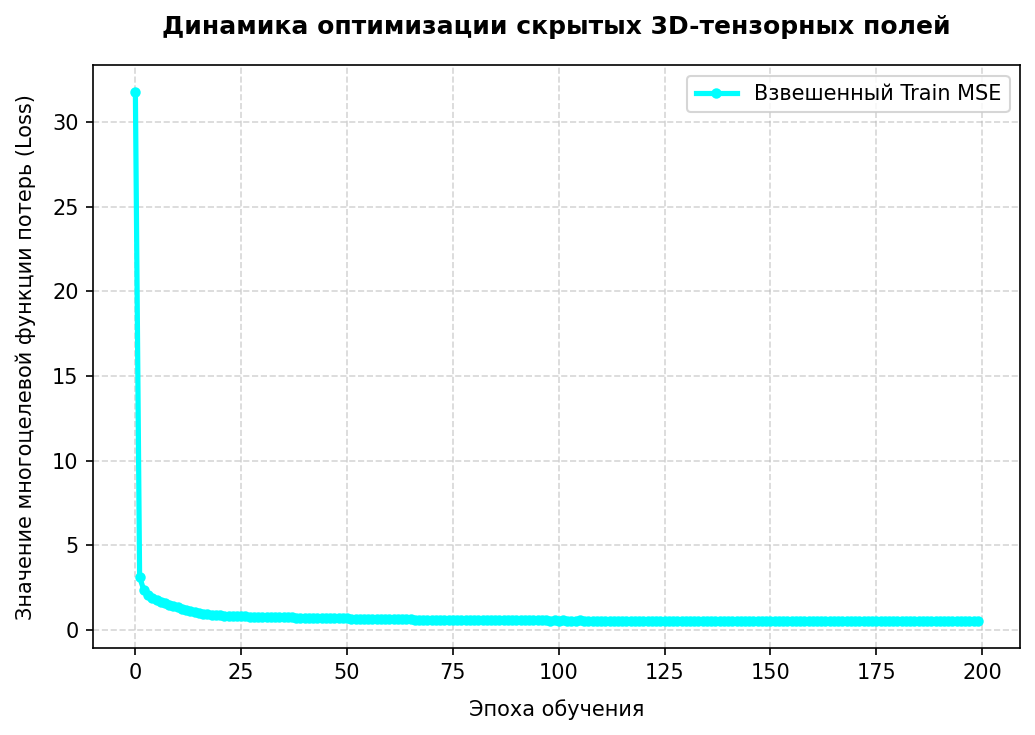

In [38]:
plt.figure(figsize=(7, 5), dpi=150)

plt.plot(
    history_loss_qm9s,
    color='cyan',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Взвешенный Train MSE'
)

plt.title('Динамика оптимизации скрытых 3D-тензорных полей', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Эпоха обучения', fontsize=10, labelpad=8)
plt.ylabel('Значение многоцелевой функции потерь (Loss)', fontsize=10, labelpad=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('qm9s_train_mse.png', dpi=300, bbox_inches='tight')
plt.show()

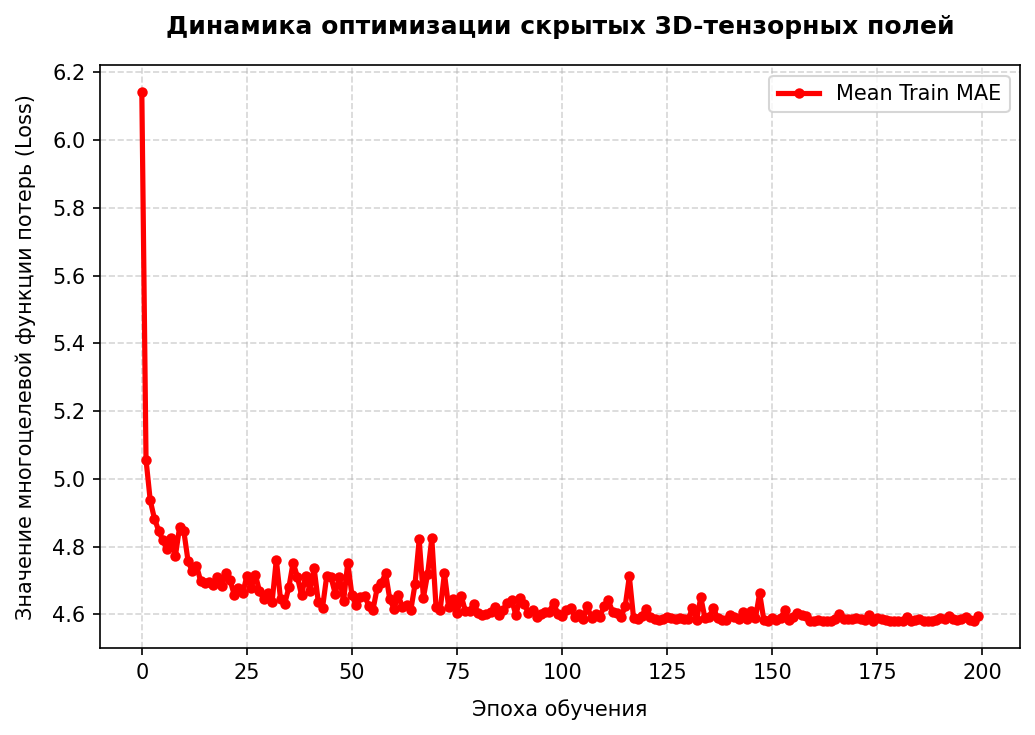

In [39]:
plt.figure(figsize=(7, 5), dpi=150)

plt.plot(
    history_mae_qm9s,
    color='red',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Mean Train MAE'
)

plt.title('Динамика оптимизации скрытых 3D-тензорных полей', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Эпоха обучения', fontsize=10, labelpad=8)
plt.ylabel('Значение многоцелевой функции потерь (Loss)', fontsize=10, labelpad=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('qm9s_train_mae.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
def qm9s_components_R2_plots(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            output = model(batch.x, batch.pos, batch.edge_index, batch.tda, batch.batch)
            targets = batch.y.view(output.size(0), 9)

            all_preds.append(output.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    colors = ['green', 'yellow', 'red']
    titles = [
        "Компоненты вектора Диполя (X, Y, Z)",
        "След матрицы Поляризуемости (0e)",
        "Девиаторные компоненты Поляризуемости (2e)"
    ]

    groups = [slice(0, 3), slice(3, 4), slice(4, 9)]

    for i, idxs in enumerate(groups):
        ax = axes[i]
        true_val = all_targets[:, idxs].flatten()
        pred_val = all_preds[:, idxs].flatten()

        mean_true = np.mean(true_val)
        ss_res = np.sum((true_val - pred_val) ** 2)
        ss_tot = np.sum((true_val - mean_true) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        ax.scatter(true_val, pred_val, alpha=0.2, color=colors[i], edgecolors='none', s=8)

        min_lim = min(true_val.min(), pred_val.min())
        max_lim = max(true_val.max(), pred_val.max())
        ax.plot([min_lim, max_lim], [min_lim, max_lim], color='black', linestyle='--', linewidth=1.5)

        ax.set_title(f"{titles[i]}\n$R^2$ = {r2:.4f}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Истинное значение (QM9Spectra)', fontsize=10)
        ax.set_ylabel('Предсказание модели (e3nn + TDA)', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig('qm9s_components_plots.png', dpi=300)
    plt.show()

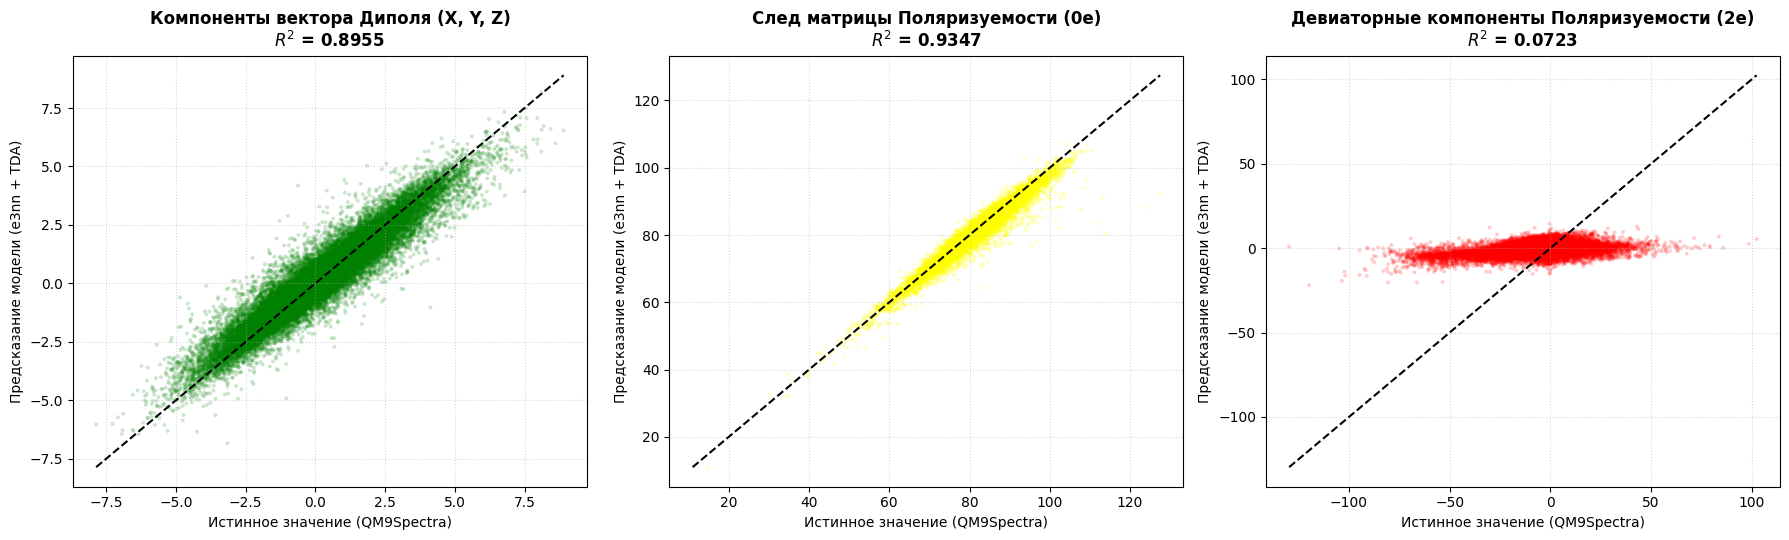

In [45]:
qm9s_components_R2_plots(model, test_loader, device)